In [1]:
import os, sys
import numpy as np
import pandas as pd

from utils.plot_utils import setup_matplotlib
from utils.quat_utils import *
from utils.metrics_utils import compute_errors, compute_simerr
from utils.plot_utils import *
from utils.latex_utils import print_latex_table_results


In [3]:
setup_matplotlib()

# === Config ===
train_trajs = ["random", "square", "chirp"]
test_trajs = ["melon"]

# === File paths ===
OUT_FOLDER = os.path.join(
    "..",
    "out",
    "predictions",
)

# Ensure the output folder exists
os.makedirs(OUT_FOLDER, exist_ok=True)

# Construct file paths
train_name = "_".join(train_trajs)
test_name = "_".join(test_trajs)

file_lstm = os.path.join(
    OUT_FOLDER,
    f"lstm_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

file_base = os.path.join(
    OUT_FOLDER,
    "baseline_model_multistep",
    f"{test_name}_multistep.csv"
)

file_mlp = os.path.join(
    OUT_FOLDER,
    f"mlp_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

file_phys = os.path.join(
    OUT_FOLDER,
    f"physics_model_multistep",
    f"{test_name}_multistep.csv"
)
#
file_hybrid = os.path.join(
    OUT_FOLDER,
    f"hybrid_{train_name}_model_multistep",
    f"{test_name}_multistep.csv"
)

print("LSTM file path:", file_lstm)
print("Baseline file path:", file_base)

# === Read CSVs ===
df_lstm = pd.read_csv(file_lstm)
df_base = pd.read_csv(file_base)
df_mlp = pd.read_csv(file_mlp)
df_phys = pd.read_csv(file_phys)
df_hybrid = pd.read_csv(file_hybrid)

print("✅ Loaded datasets:")
print(f"  LSTM model: {df_lstm.shape}")
print(f"  Baseline model: {df_base.shape}")
print(f"  MLP model: {df_mlp.shape}")
print(f"  Physics model: {df_phys.shape}")
print(f"  Hybrid model: {df_hybrid.shape}")

LSTM file path: ../out/predictions/lstm_random_square_chirp_model_multistep/melon_multistep.csv
Baseline file path: ../out/predictions/baseline_model_multistep/melon_multistep.csv
✅ Loaded datasets:
  LSTM model: (19347, 613)
  Baseline model: (19347, 613)
  MLP model: (19347, 613)
  Physics model: (19347, 613)
  Hybrid model: (19347, 613)


In [4]:
print(df_lstm.columns.tolist())
print(df_lstm.shape)

['t', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'rx', 'ry', 'rz', 'wx', 'wy', 'wz', 'x_pred_h1', 'y_pred_h1', 'z_pred_h1', 'vx_pred_h1', 'vy_pred_h1', 'vz_pred_h1', 'rx_pred_h1', 'ry_pred_h1', 'rz_pred_h1', 'wx_pred_h1', 'wy_pred_h1', 'wz_pred_h1', 'x_pred_h2', 'y_pred_h2', 'z_pred_h2', 'vx_pred_h2', 'vy_pred_h2', 'vz_pred_h2', 'rx_pred_h2', 'ry_pred_h2', 'rz_pred_h2', 'wx_pred_h2', 'wy_pred_h2', 'wz_pred_h2', 'x_pred_h3', 'y_pred_h3', 'z_pred_h3', 'vx_pred_h3', 'vy_pred_h3', 'vz_pred_h3', 'rx_pred_h3', 'ry_pred_h3', 'rz_pred_h3', 'wx_pred_h3', 'wy_pred_h3', 'wz_pred_h3', 'x_pred_h4', 'y_pred_h4', 'z_pred_h4', 'vx_pred_h4', 'vy_pred_h4', 'vz_pred_h4', 'rx_pred_h4', 'ry_pred_h4', 'rz_pred_h4', 'wx_pred_h4', 'wy_pred_h4', 'wz_pred_h4', 'x_pred_h5', 'y_pred_h5', 'z_pred_h5', 'vx_pred_h5', 'vy_pred_h5', 'vz_pred_h5', 'rx_pred_h5', 'ry_pred_h5', 'rz_pred_h5', 'wx_pred_h5', 'wy_pred_h5', 'wz_pred_h5', 'x_pred_h6', 'y_pred_h6', 'z_pred_h6', 'vx_pred_h6', 'vy_pred_h6', 'vz_pred_h6', 'rx_pred_h6', 'ry_p

In [3]:
def add_rotation_columns(df):
    df = df.copy()
    new_cols = {}

    # Find all rotation-vector triplets: rx*, ry*, rz*
    rx_cols = [c for c in df.columns if c.startswith("rx")]

    for rx_col in rx_cols:
        suffix = rx_col[2:]
        ry_col = f"ry{suffix}"
        rz_col = f"rz{suffix}"

        if ry_col not in df.columns or rz_col not in df.columns:
            continue

        # Extract rotation vectors
        r = df[[rx_col, ry_col, rz_col]].to_numpy(float)

        # Convert to quaternion (N,4)
        q = so3_log_to_quat_np(r)

        new_cols[f"qx{suffix}"] = q[:, 0]
        new_cols[f"qy{suffix}"] = q[:, 1]
        new_cols[f"qz{suffix}"] = q[:, 2]
        new_cols[f"qw{suffix}"] = q[:, 3]

        # Euler angles
        e = quat_to_euler_np(q)

        new_cols[f"roll{suffix}"]  = e[:, 0]
        new_cols[f"pitch{suffix}"] = e[:, 1]
        new_cols[f"yaw{suffix}"]   = e[:, 2]

        # Degrees
        new_cols[f"roll{suffix}_deg"]  = np.degrees(e[:, 0])
        new_cols[f"pitch{suffix}_deg"] = np.degrees(e[:, 1])
        new_cols[f"yaw{suffix}_deg"]   = np.degrees(e[:, 2])

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df

In [4]:
# ---------------------------------------------------------
# === Apply to all dataframes ===
# ---------------------------------------------------------
df_base, df_lstm, df_mlp, df_phys, df_hybrid = [
    add_rotation_columns(df)
    for df in [df_base, df_lstm, df_mlp, df_phys, df_hybrid]
]
# --- Config ---
max_horizon = 50

metrics_base   = compute_errors(df_base,   max_horizon)
metrics_lstm   = compute_errors(df_lstm,   max_horizon)
metrics_mlp    = compute_errors(df_mlp,    max_horizon)
metrics_phys   = compute_errors(df_phys,   max_horizon)
metrics_hybrid = compute_errors(df_hybrid, max_horizon)

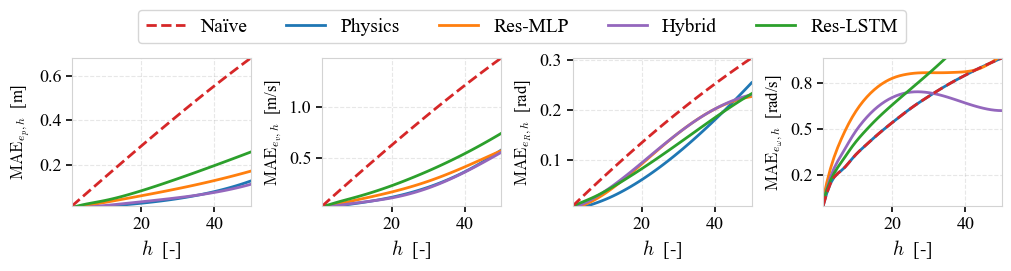

In [5]:
import matplotlib.pyplot as plt
model_metrics = {
    "Physics":   metrics_phys,
    "Res-MLP":  metrics_mlp,
    "Hybrid":  metrics_hybrid,
    "Res-LSTM":      metrics_lstm,
    "Naïve":  metrics_base,
}

plot_metrics(model_metrics, save_fig=False)

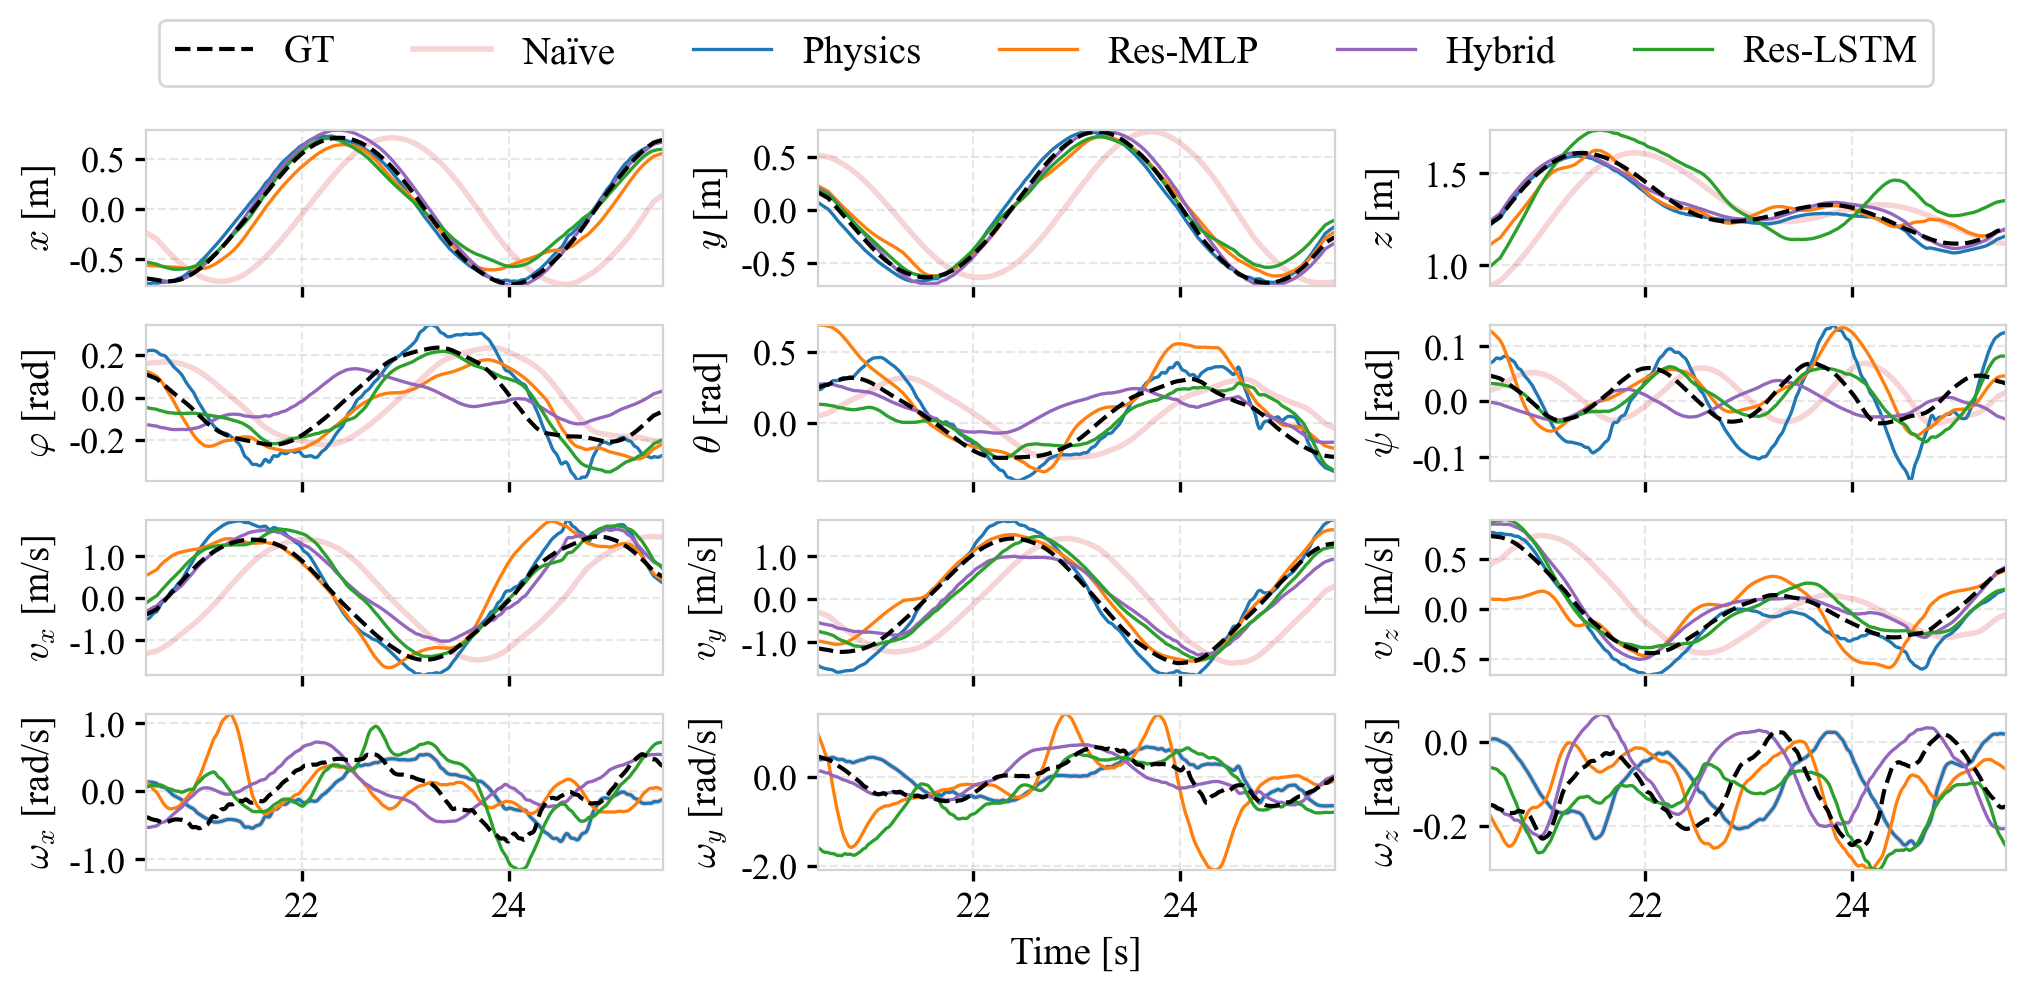

In [6]:
dfs = {
    "Physics":  df_phys,
    "Res-MLP":  df_mlp,
    "Hybrid":   df_hybrid,
    "Res-LSTM": df_lstm,
    "Naive":    df_base,
}

N_start = 2000
N_end = N_start + 500
plot_multistate_predictions(dfs, h=50, N_start=N_start, N_end=N_end, save_fig=False)

In [7]:
import numpy as np
import pandas as pd

# ============================================================
# === CONFIG
# ============================================================
H_TARGETS = [1, 10, 50]

model_order = ["Naïve", "Physics", "MLP", "Hybrid", "LSTM"]

model_metrics = {
    "Naïve": metrics_base,
    "Physics":  metrics_phys,
    "MLP": metrics_mlp,
    "Hybrid": metrics_hybrid,
    "LSTM":     metrics_lstm,
}

# ============================================================
# === Build rows
# ============================================================
rows = []
for model_name in model_order:
    mm = model_metrics[model_name]

    pos_vals = [mm["pos"][h] for h in H_TARGETS]
    vel_vals = [mm["vel"][h] for h in H_TARGETS]
    rot_vals = [mm["rot"][h] for h in H_TARGETS]
    omg_vals = [mm["omega"][h] for h in H_TARGETS]

    sim_p, sim_v, sim_R, sim_w = compute_simerr(mm)

    rows.append([
        model_name,
        *pos_vals, sim_p,
        *vel_vals, sim_v,
        *rot_vals, sim_R,
        *omg_vals, sim_w,
    ])


print_latex_table_results(rows, H_TARGETS)


    \begin{table*}[t]
        \centering
        \caption{Numerical performance at $h=1,10,50$. The italic column reports the cumulative simulation error (sum of MAEs over $h=1..50$).}
        \setlength{\tabcolsep}{3pt}
        \scriptsize
        \renewcommand{\arraystretch}{1.2}
        \begin{tabular}{l|cccc|cccc|cccc|cccc}
            \toprule
            & \multicolumn{4}{c|}{$\mathrm{MAE}_{p,h}$ [m]}
            & \multicolumn{4}{c|}{$\mathrm{MAE}_{v,h}$ [m/s]}
            & \multicolumn{4}{c|}{$\mathrm{MAE}_{R,h}$ [rad]}
            & \multicolumn{4}{c}{$\mathrm{MAE}_{\omega,h}$ [rad/s]}\\m]

            Model
            & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
            & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
            & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}
            & $h{=}1$ & $h{=}10$ & $h{=}50$ & \textit{$h{=}1{:}50$}\\
            \midrule
    \toprule
\midrule
Naïve & 0.0143 & 0.1430 & 0.6797 & 17.7878 & 0.0329 & 0.